In [28]:
#importing the required libraries for classification using XGBoost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder,StandardScaler
from xgboost import XGBClassifier
# from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
import joblib
import warnings
warnings.filterwarnings('ignore')

In [29]:
# Loading the laon dataset
df = pd.read_csv(r"D:\Three-capstone-projects\machine_fault_diagnosis\dataset\ai4i2020.csv")

In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [30]:
# drop the id columns 
df = df.drop(['UDI','Product ID'], axis=1)

In [31]:
df.shape

(10000, 12)

In [32]:
# check for the missing values
df.isnull().sum()

Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [30]:
# Check for the duplicated rows
df.duplicated().sum()

np.int64(0)

In [31]:
df.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


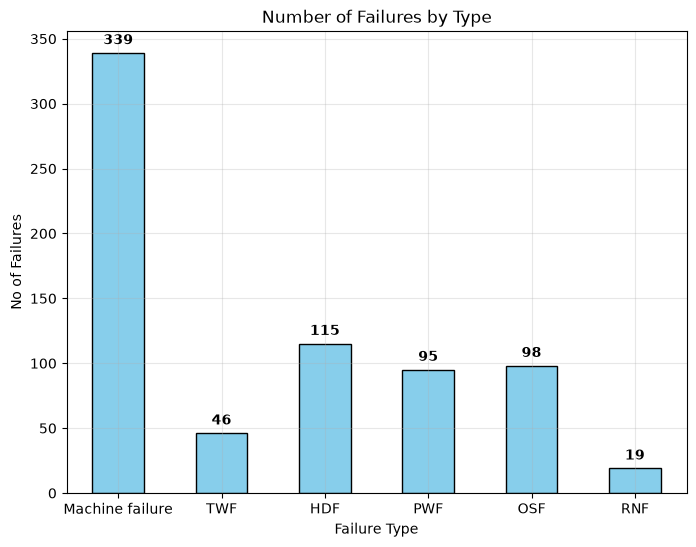

In [54]:
# total number of failure counts within dataset 
failure_counts = df[["Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]].sum()
ax = failure_counts.plot(kind='bar', figsize=(8, 6), color='skyblue', edgecolor='black')
# Display total number of count on the top
for container in ax.containers:
    ax.bar_label(container, padding=4, fontsize=10, fontweight='bold')
plt.title('Number of Failures by Type')
plt.xlabel('Failure Type')
plt.ylabel('No of Failures')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=0)
plt.show()

In [65]:
# Saving the numercial attributes
numeric_features = df[["Air temperature [K]","Process temperature [K]","Rotational speed [rpm]","Torque [Nm]","Tool wear [min]"]]
numeric_features.head(2)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,298.1,308.6,1551,42.8,0
1,298.2,308.7,1408,46.3,3


In [66]:
# Saving the categorical features
categorical_features = df.select_dtypes(include=['object'])
categorical_features.head(3)

,Type
0,M
1,L
2,L


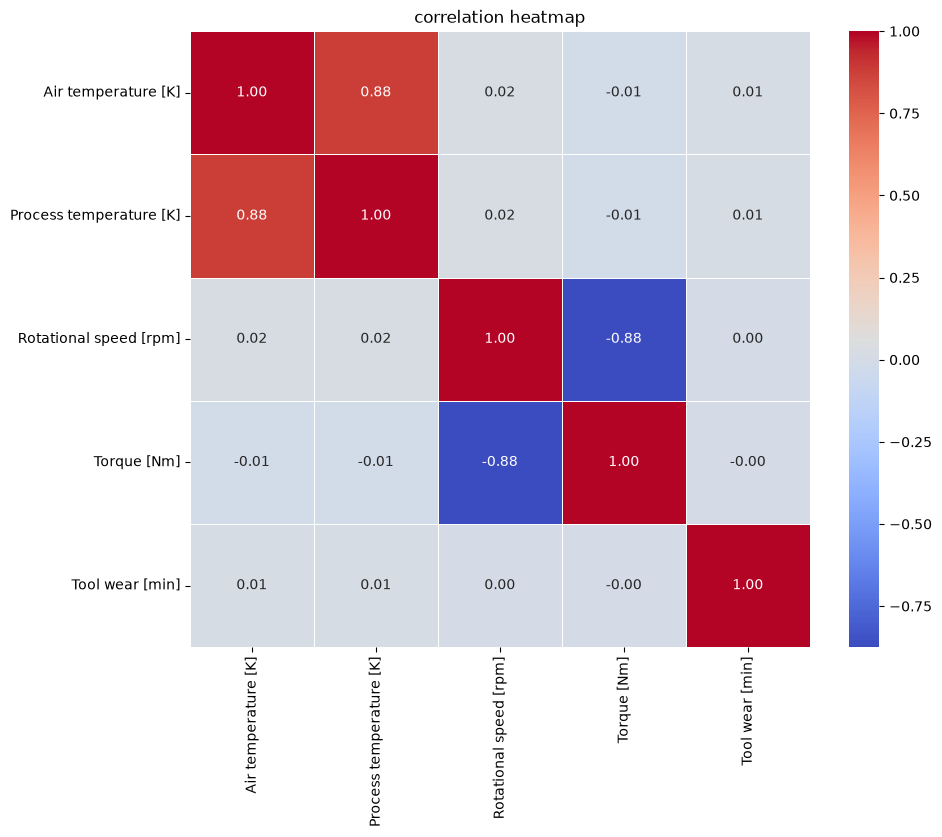

In [67]:
corr = numeric_features.corr()
plt.figure(figsize=(10,8)) # figure size to fit into window
sns.heatmap(corr,annot=True,fmt='0.2f',cmap='coolwarm',linewidths=0.5,)
plt.title("correlation heatmap")
plt.show()

Air Temperature and Process Temperature  have strong positive correlation (r = 0.88), as ambient temperatures directly correspond to higher operational process i.e. heat. In contrast, Rotational Speed and Torque demonstrate a strong inverse relationship (r = -0.88), reflecting standard mechanical power dynamics where speed increases at the expense of torque.

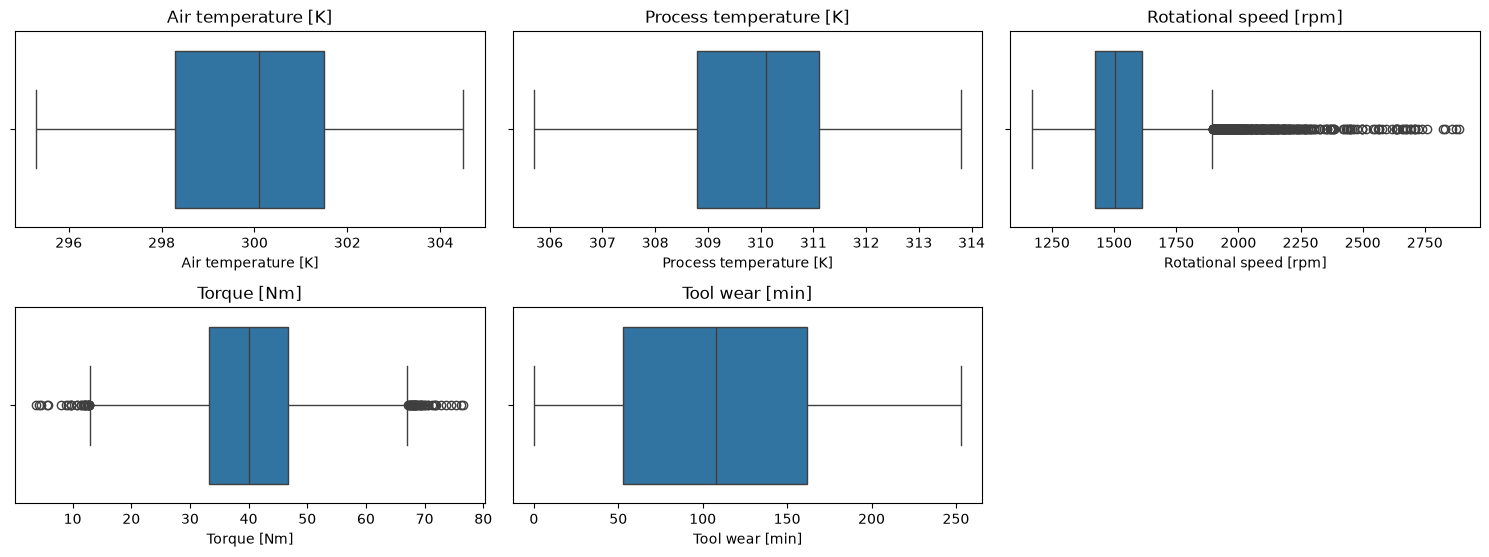

In [70]:
# Analyzing the numerical features by using box plot
plt.figure(figsize=(15,8))
for i ,col in enumerate(numeric_features):
    plt.subplot(3,3,i+1) # i+1 to start index from 1
    sns.boxplot(data=df,x=col)
    plt.title(col)
plt.tight_layout()
plt.show()

The exterme values of Rotational speed and Torgue are crucial predictive signals that provide failure infomation about classes of specific industrial failure, so capping or removing them would destroy key diagnostic patterns.Instead, we can use tree based alogrithims that rely on rank-based threshold splits rather than feature scale or distance calculations. Tree models select features greedily at each node based on information gain. The strong inverse correlation (r = -0.88) between Torque and Rotational Speed will not destabilize tree-based algorithms, unlike linear models.

In [18]:
df.shape

(43370, 14)

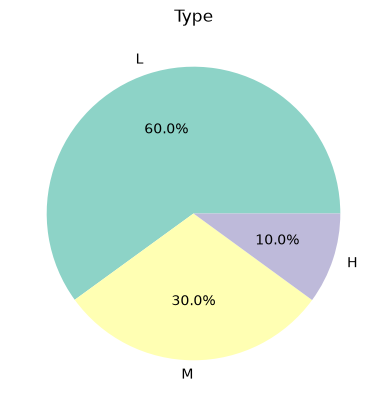

In [76]:
# visualizing the categorical variables on pie chat
plt.figure(figsize=(15,8))
for i, col in enumerate(categorical_features.columns, start=1):
    plt.subplot(2, 3, i)
    counts = df[col].value_counts()
    # setting pie chart prperties
    plt.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        colors=plt.cm.Set3.colors
    )
    plt.title(col)

plt.tight_layout()
plt.show()

In [82]:
# Add a failure type column in the dataset that would be target variable
def multi_class_target(row):
    
    if row['TWF'] == 1:
        return 1  # Tool Wear Failure
    elif row['HDF'] == 1:
        return 2  # Heat Dissipation Failure
    elif row['PWF'] == 1:
        return 3  # Power Failure
    elif row['OSF'] == 1:
        return 4  # Overstrain Failure
    elif row['RNF'] == 1: #or row["Machine failure"] == 1:
        return 5  # / General / Random Failure
    elif row["Machine failure"] == 1:
        return 6  # Other / General Failure
    else:
        return 0  # No Failure

In [113]:
df['failue_type'] = df.apply(multi_class_target, axis=1)
print(f"Class Distribution")
counts = df['failue_type'].value_counts().sort_index()
names = ["No Failure", "TWF", "HDF", "PWF", "OSF", "RNF", "others"]
counts.index = names
print(counts)

Class Distribution
No Failure    9643
TWF             46
HDF            115
PWF             91
OSF             78
RNF             18
others           9
Name: count, dtype: int64


In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  str    
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Machine failure          10000 non-null  int64  
 7   TWF                      10000 non-null  int64  
 8   HDF                      10000 non-null  int64  
 9   PWF                      10000 non-null  int64  
 10  OSF                      10000 non-null  int64  
 11  RNF                      10000 non-null  int64  
 12  failue_type              10000 non-null  int64  
dtypes: float64(3), int64(9), str(1)
memory usage: 1.0 MB


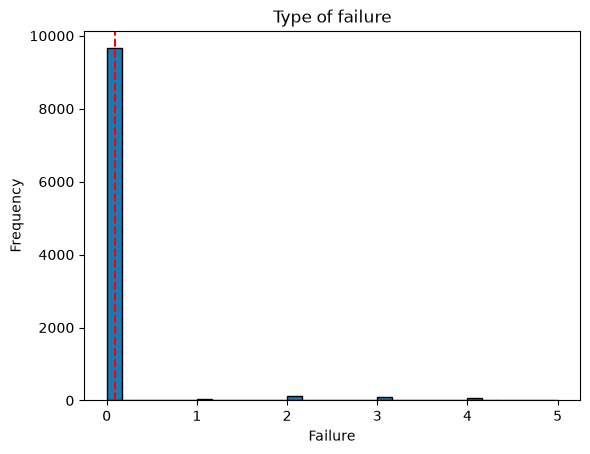

In [81]:
# To see the failue type distribution use histo-gram plotting
plt.hist(df["failue_type"],bins=30,edgecolor="black")
plt.axvline(df["failue_type"].mean(), color="red", linestyle="--", label="Mean")
plt.title("Type of failure")
plt.xlabel("Failure")
plt.ylabel("Frequency")
plt.show()

The histogram illustrates extreme class imbalance, where Class 0 ("No Failure") overwhelmingly dominates the dataset with over 96.5% of samples, leaving failure classes 1 through 5 nearly invisible. To handle this issue, SMOTE synthetically generates new minority class samples by interpolating between k-nearest neighbors in the feature space. On the other hand tree-based algorithms can tackle the imbalance natively using cost-sensitive learning (setting class_weight='balanced' in Random Forest or tuning scale_pos_weight in XGBoost/LightGBM) to penalize misclassifications of rare failure modes. we would use both techniques to handle imbalacing effectively.

In [84]:
# Seprate the features and target variables
X = df[["Air temperature [K]","Process temperature [K]","Rotational speed [rpm]","Torque [Nm]","Tool wear [min]","Type"]]
y = df['failue_type']
X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type
0,298.1,308.6,1551,42.8,0,M
1,298.2,308.7,1408,46.3,3,L
2,298.1,308.5,1498,49.4,5,L
3,298.2,308.6,1433,39.5,7,L
4,298.2,308.7,1408,40.0,9,L


In [93]:
X.dtypes

Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Type                           str
dtype: object

In [85]:
# seprtating the categorical features and saving in the list format
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64','float64']).columns.to_list()

In [86]:
# Splitting the dataset into X test and y train data using stranified to preserve rare failure classes in test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [87]:
# defining preprocessor pipline to use columntransformer production standard
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OrdinalEncoder(categories=[['L', 'M', 'H']]), # encoding using ordinal encode for categorical variables of training data
            categorical_cols
        ),
        (
            "num",
            StandardScaler(),
            numerical_cols
        )
    ]

    # remainder="passthrough" # plan to use XGBclassifier which does not require scaling of numerical variables
)

In [97]:
# SMOTE works seamlessly on multi-class targets using k-NN per class
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=3)),  # Low k for rare classes like RNF
    ('classifier', RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=42))
])

# ==========================================
# 4. TRAIN AND EVALUATE
# ==========================================
print("\nTraining Multi-Class Model Pipeline...")
model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

target_names = ['No Failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF','others']
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))


Training Multi-Class Model Pipeline...

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  No Failure       0.99      0.98      0.98      1928
         TWF       0.00      0.00      0.00         9
         HDF       0.70      0.83      0.76        23
         PWF       0.56      0.78      0.65        18
         OSF       0.71      0.75      0.73        16
         RNF       0.00      0.00      0.00         4
      others       0.00      0.00      0.00         2

    accuracy                           0.97      2000
   macro avg       0.42      0.48      0.45      2000
weighted avg       0.97      0.97      0.97      2000



In [116]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=3)),  # Low k for rare classes like RNF
    ('classifier', XGBClassifier(
            n_estimators=100, 
            # scale_pos_weight=ratio,  # Handles class imbalance in XGBoost
            eval_metric='logloss',
            random_state=42
        ))
])

# ==========================================
# 4. TRAIN AND EVALUATE
# ==========================================
print("\nTraining Multi-Class Model Pipeline...")
xgb_pipeline.fit(X_train, y_train)

y_pred = xgb_pipeline.predict(X_test)

target_names = ['No Failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF','others']
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))


Training Multi-Class Model Pipeline...

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  No Failure       0.99      0.98      0.99      1928
         TWF       0.05      0.11      0.07         9
         HDF       0.87      0.87      0.87        23
         PWF       0.79      0.83      0.81        18
         OSF       0.75      0.94      0.83        16
         RNF       0.00      0.00      0.00         4
      others       0.00      0.00      0.00         2

    accuracy                           0.97      2000
   macro avg       0.49      0.53      0.51      2000
weighted avg       0.98      0.97      0.97      2000



In [118]:
from lightgbm import LGBMClassifier
# Create preprocessor step
preprocessor = ColumnTransformer(
    transformers=[("cat", OrdinalEncoder(), categorical_cols)], remainder="passthrough"
)

# Combine into the imblearn pipeline
lgbm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(k_neighbors=3, random_state=42)),
        (
            "model",
            LGBMClassifier(
                objective="multiclass",
                num_class=7,
                n_estimators=100,
                learning_rate=0.05,
                class_weight="balanced",
                random_state=42,
                verbosity=-1,
            ),
        ),
    ]
)

# Fit and predict
lgbm_pipeline.fit(X_train, y_train)
y_pred = lgbm_pipeline.predict(X_test)
# Print performance metrics
target_names = ['No Failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF','others']
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  No Failure       0.99      0.97      0.98      1928
         TWF       0.00      0.00      0.00         9
         HDF       0.82      1.00      0.90        23
         PWF       0.79      0.83      0.81        18
         OSF       0.81      0.81      0.81        16
         RNF       0.00      0.00      0.00         4
      others       0.00      0.00      0.00         2

    accuracy                           0.96      2000
   macro avg       0.49      0.52      0.50      2000
weighted avg       0.98      0.96      0.97      2000



In [103]:
joblib.dump(model_pipeline,"RandomForest.joblib")

['RandomForest.joblib']

In [119]:
joblib.dump(lgbm_pipeline,"LightGBM.joblib")

['LightGBM.joblib']

In [101]:
joblib.dump(xgb_pipeline,"xgb_model.joblib")

['xgb_model.joblib']

In [ ]:
rf_model = joblib.load('RandomForest.joblib')
lgbm__model = joblib.load('LightGBM.joblib')
xgb_model = joblib.load('xgb_model.joblib')
test_sample = pd.DataFrame(
    [
        {
            "Type": "L",
            "Air temperature [K]": 297.2,
            "Process temperature [K]": 308.1,
            "Rotational speed [rpm]": 1431,
            "Torque [Nm]": 49.7,
            "Tool wear [min]": 210,
        }
    ])
# Making predictions from each model
rf_prediction = rf_model.predict(test_sample)[0]
lgbm_prediction = lgbm__model.predict(test_sample)[0]
xgb_prediction = xgb_model.predict(test_sample)[0]
# calculating probabilities of each prediction
rf_probability = rf_model.predict_proba(test_sample)[0]
lgbm_probability= lgbm__model.predict_proba(test_sample)[0]
xgb_probability = xgb_model.predict_proba(test_sample)[0]
# final_index = np.argmax(xgb_probability)
# confidence = xgb_probability[final_index]
# print(confidence)

ensemble_probability = (rf_probability + lgbm_probability + xgb_probability) / 3

classes = rf_model.classes_
final_index = np.argmax(ensemble_probability)
# Define class map matching your dataset encoding
class_names = {
    0: "No Failure",
    1: "TWF",
    2: "HDF",
    3: "PWF",
    4: "OSF",
    5: "RNF",
    6: "Others"
}
machine_failure = "No" if classes[0] == True else "Yes"
print(machine_failure)
final_prediction = class_names[final_index]
print(final_prediction)
confidence = f"{ensemble_probability[final_index]* 100:.2f} %"
print(confidence)

results = {
    "Machine Failure": machine_failure,  # Output: 1
    "Failure Type": final_prediction,  # Output: 'Heat Dissipation Failure (HDF)'
    "Confidence" : confidence,
}
print(results)

Yes
Others
91.18 %
{'Machine Failure': 'Yes', 'Failure Type': 'Others', 'Confidence': '91.18 %'}


In [120]:
# 1. Load your saved pipeline 
model = joblib.load("xgb_model.joblib")

# 2. Replicate the HDF rows from your image into a DataFrame
hdf_test_samples = pd.DataFrame(
    [
        {
            "Type": "L",
            "Air temperature [K]": 297.2,
            "Process temperature [K]": 308.1,
            "Rotational speed [rpm]": 1431,
            "Torque [Nm]": 49.7,
            "Tool wear [min]": 210,
        },
        {
            "Type": "L",
            "Air temperature [K]": 301.7,
            "Process temperature [K]": 310.9,
            "Rotational speed [rpm]": 1405,
            "Torque [Nm]": 46.4,
            "Tool wear [min]": 207,
        },
    ]
)

# 3. Get predicted class labels (e.g., encoded target for HDF)
predictions = model.predict(hdf_test_samples)
print("Predicted Class Codes:", predictions)

# 4. Get probability distribution across all failure classes
probabilities = model.predict_proba(hdf_test_samples)
print("Predicted Class Probabilities:\n", probabilities)

Predicted Class Codes: [6 1]
Predicted Class Probabilities:
 [[7.64065050e-03 1.00859805e-04 8.40269513e-06 1.53285400e-05
  1.22213212e-04 1.14992451e-06 9.92111325e-01]
 [2.66834404e-02 9.73291874e-01 5.76090906e-06 6.53768484e-06
  1.21432122e-05 1.58741159e-07 1.14511572e-07]]


In [111]:
import numpy as np

# Prediction output from your model pipeline
class_code = predictions[1]  # e.g., 2 (HDF)

# Map class code to 0 (No Failure) or 1 (Machine Failure)
machine_failure = "No" if class_code == 0 else "Yes"

# Define class map matching your dataset encoding
class_names = [
    "No Failure",
    "Tool Wear Failure (TWF)",
    "Heat Dissipation Failure (HDF)",
    "Power Failure (PWF)",
    "Overstrain Failure (OSF)",
    "Random Failure (RNF)",
    "Other Machine Failure"
]

# Map predictions
predicted_labels = [class_names[i] for i in predictions]

for idx, (label, proba) in enumerate(zip(predicted_labels, probabilities)):
    max_prob = np.max(proba) * 100
    print(f"Sample {idx + 1}: {label} ({max_prob:.2f}% confidence)")

results = {
    "Machine Failure": machine_failure,  # Output: 1
    "Failure Type": class_names[class_code],  # Output: 'Heat Dissipation Failure (HDF)'
    "Confidence": f"{np.max(probabilities[0]) * 100:.2f}%",
}
print(results)
for result, value in results.items():
    print(f"{result} : {value}")
print(result)

Sample 1: Other Machine Failure (99.21% confidence)
Sample 2: Tool Wear Failure (TWF) (97.33% confidence)
{'Machine Failure': 'Yes', 'Failure Type': 'Tool Wear Failure (TWF)', 'Confidence': '99.21%'}
Machine Failure : Yes
Failure Type : Tool Wear Failure (TWF)
Confidence : 99.21%
Confidence
